In [42]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint

In [43]:
historic_data = pd.read_csv('data/combined_data/historical/historical_lakevic_data.csv')
#historic_data.describe(include='all')
historic_data.drop(historic_data[historic_data['region'].str.contains('Victoria Nile', case=False, na=False)].index, inplace=True)
#historic_data.describe(include='all')


In [121]:
y = historic_data.runoff
X = historic_data.drop(columns='runoff')

numerical_features = ['year', 'rainfall']
categorical_features = ['month', 'region']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat_transform', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ],
    remainder='passthrough'
)


In [122]:
#Let's test splitting data at this stage
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.25, random_state=2)

In [123]:
X_train_processed = preprocessor.fit_transform(train_x)
X_test_processed = preprocessor.transform(test_x)


In [130]:
cat_names = preprocessor.named_transformers_['cat_transform'].get_feature_names_out(categorical_features)
column_names = numerical_features + list(cat_names)
print(len(column_names))
X_train_df = pd.DataFrame(X_train_processed, columns=column_names)
X_test_df = pd.DataFrame(X_test_processed, columns=column_names)
X_test_df

17


,year,rainfall,month_April,month_Aug.,month_Dec.,month_Feb.,month_Jan.,month_July,month_June,month_March,month_May,month_Nov.,month_Oct.,month_Sept.,region_Kagera,region_Lake Victoria,region_Simiyu
0,1.517702,1.678743,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.517702,-0.797927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.601776,-0.842581,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.923629,-0.838815,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.568295,-0.758115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,-0.923629,-0.106601,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
224,-0.516740,-0.034778,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
225,1.382072,1.704298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
226,-1.330517,-0.838815,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
flood_model = GradientBoostingRegressor(random_state=2)
flood_model.fit(X_train_processed, train_y)

params = flood_model.get_params()

# Print them
for param, value in params.items():
    print(f"{param}: {value}")

alpha: 0.9
ccp_alpha: 0.0
criterion: friedman_mse
init: None
learning_rate: 0.1
loss: squared_error
max_depth: 3
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
n_estimators: 100
n_iter_no_change: None
random_state: 2
subsample: 1.0
tol: 0.0001
validation_fraction: 0.1
verbose: 0
warm_start: False


In [126]:
random_model = RandomForestRegressor(random_state=2)
random_model.fit(X_train_processed, train_y)

RandomForestRegressor(random_state=2)

In [134]:
params_grid = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.6, 0.4)
}
random_search = RandomizedSearchCV(
    estimator=flood_model,
    param_distributions=params_grid,
    n_iter=100,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [135]:
random_search.fit(X_train_processed, train_y)
print("RandomizedSearchCV complete.")
print(f"Best parameters found by RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score : {random_search.best_score_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
RandomizedSearchCV complete.
Best parameters found by RandomizedSearchCV: {'learning_rate': 0.024552601272838707, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 128, 'subsample': 0.6339350856340767}
Best cross-validation score : 0.6021544016612781


In [129]:
predictions = flood_model.predict(X_test_processed)
print("\nMAE : ", mean_absolute_error(test_y, predictions))
print("\nMSE : ", mean_squared_error(test_y, predictions))
print("\nR2 : ", r2_score(test_y, predictions))


MAE :  140.47223591383346

MSE :  75618.80895016127

R2 :  0.7761583873650104


In [41]:
predictions = random_model.predict(X_test_processed)
print("\nMAE : ", mean_absolute_error(test_y, predictions))
print("\nMSE : ", mean_squared_error(test_y, predictions))
print("\nR2 : ", r2_score(test_y, predictions))
print("\nMAPE : ", mean_absolute_percentage_error(test_y, predictions))


MAE :  133.87662855263156

MSE :  83382.06953631916

R2 :  0.7531781157495643

MAPE :  1254064056133175.5


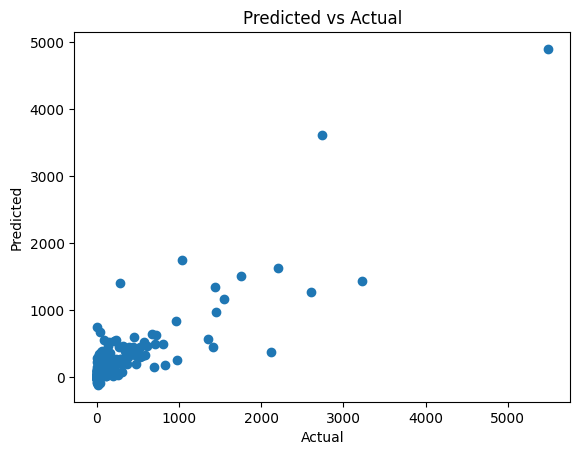

In [37]:
import matplotlib.pyplot as plt
plt.scatter(test_y, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()
